Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**  
Course: **Computer Engineering - Artificial Intelligence / Machine Learning**

**ASSESSMENT 1 - 10 Slope Prediction Model**


---

#### **I. Import Libraries and Initialize Functions**

In [1]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

I0000 00:00:1778691009.291103   99551 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


In [2]:
def pltpred (train_data, 
             train_labels,
             test_data, 
             test_labels,
             predictions):
    
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", label="Training data")
    plt.scatter(test_data, test_labels, c="g", label="Testing data")
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend();

#### **II. Prep Dataset**

Create the dataset.

In [3]:
# Create features
x = np.arange(-200, 200, 4)

# Create labels
y = x + 20


x, y 

(array([-200, -196, -192, -188, -184, -180, -176, -172, -168, -164, -160,
        -156, -152, -148, -144, -140, -136, -132, -128, -124, -120, -116,
        -112, -108, -104, -100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,
         -68,  -64,  -60,  -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,
         -24,  -20,  -16,  -12,   -8,   -4,    0,    4,    8,   12,   16,
          20,   24,   28,   32,   36,   40,   44,   48,   52,   56,   60,
          64,   68,   72,   76,   80,   84,   88,   92,   96,  100,  104,
         108,  112,  116,  120,  124,  128,  132,  136,  140,  144,  148,
         152,  156,  160,  164,  168,  172,  176,  180,  184,  188,  192,
         196]),
 array([-180, -176, -172, -168, -164, -160, -156, -152, -148, -144, -140,
        -136, -132, -128, -124, -120, -116, -112, -108, -104, -100,  -96,
         -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,  -56,  -52,
         -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,  -12,   -8,
          -4,    0,   

Split the dataset into training and testing sets.

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size= 0.2,
                                                    random_state=42,
                                                    shuffle=False
                                                    )

Normalize the data using `StandardScaler()` (for models that require it)

In [5]:
scaler = StandardScaler()

x_train_reshaped = x_train.reshape(-1, 1)
x_test_reshaped = x_test.reshape(-1, 1)

x_train_scaled = scaler.fit_transform(x_train_reshaped)
x_test_scaled = scaler.transform(x_test_reshaped)

x_train_scaled, x_test_scaled, x_train, x_test

(array([[-1.71053381],
        [-1.66722916],
        [-1.62392451],
        [-1.58061985],
        [-1.5373152 ],
        [-1.49401055],
        [-1.45070589],
        [-1.40740124],
        [-1.36409659],
        [-1.32079193],
        [-1.27748728],
        [-1.23418262],
        [-1.19087797],
        [-1.14757332],
        [-1.10426866],
        [-1.06096401],
        [-1.01765936],
        [-0.9743547 ],
        [-0.93105005],
        [-0.8877454 ],
        [-0.84444074],
        [-0.80113609],
        [-0.75783144],
        [-0.71452678],
        [-0.67122213],
        [-0.62791748],
        [-0.58461282],
        [-0.54130817],
        [-0.49800352],
        [-0.45469886],
        [-0.41139421],
        [-0.36808955],
        [-0.3247849 ],
        [-0.28148025],
        [-0.23817559],
        [-0.19487094],
        [-0.15156629],
        [-0.10826163],
        [-0.06495698],
        [-0.02165233],
        [ 0.02165233],
        [ 0.06495698],
        [ 0.10826163],
        [ 0

Visualize the data.

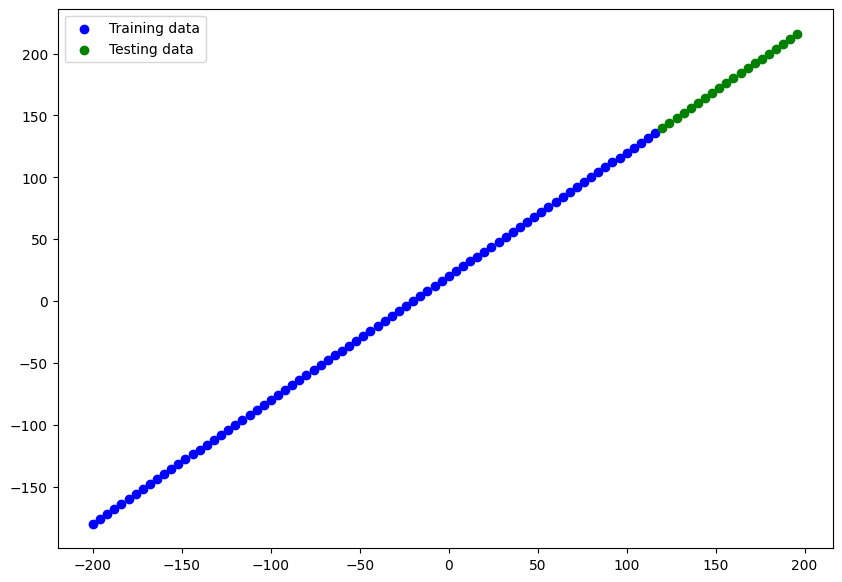

In [6]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(x_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(x_test, y_test, c='g', label='Testing data')
# Show the legend
plt.legend();

#### **III. Create Models**

#### **Model 1 - Barebone Single Neuron Approach**

The simplest / barebones model.

##### Create and compile model

In [7]:
model1 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model1.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

I0000 00:00:1778691016.963841   99551 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


##### Show model summary

In [8]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [9]:
history1 = model1.fit(x_train, y_train, 
                      epochs=5)

Epoch 1/5


I0000 00:00:1778691019.375099   99755 service.cc:153] XLA service 0x7d3a7802fa90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778691019.375166   99755 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1778691019.401710   99755 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778691019.468831   99755 cuda_dnn.cc:461] Loaded cuDNN version 92000


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 1839.0228 - mse: 1839.0228

I0000 00:00:1778691019.736766   99755 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 1700.8577 - mse: 1700.8577
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1677.4697 - mse: 1677.4697
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1656.9320 - mse: 1656.9320
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1634.5254 - mse: 1634.5254
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1613.1624 - mse: 1613.1624


Evaluate the model.

In [10]:
model1.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 7895.5415 - mse: 7895.5415


[7895.54150390625, 7895.54150390625]

##### Showcase results.

In [11]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

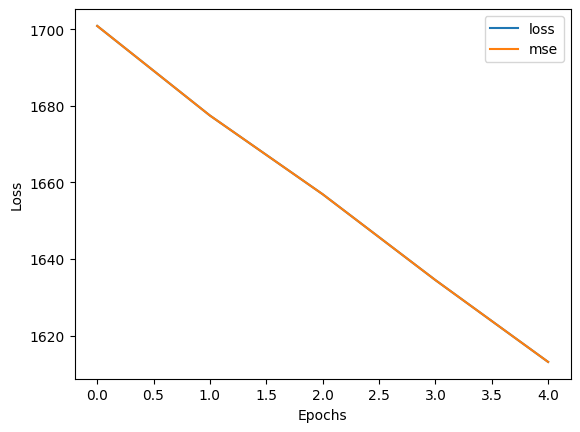

In [12]:
pd.DataFrame(history1.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


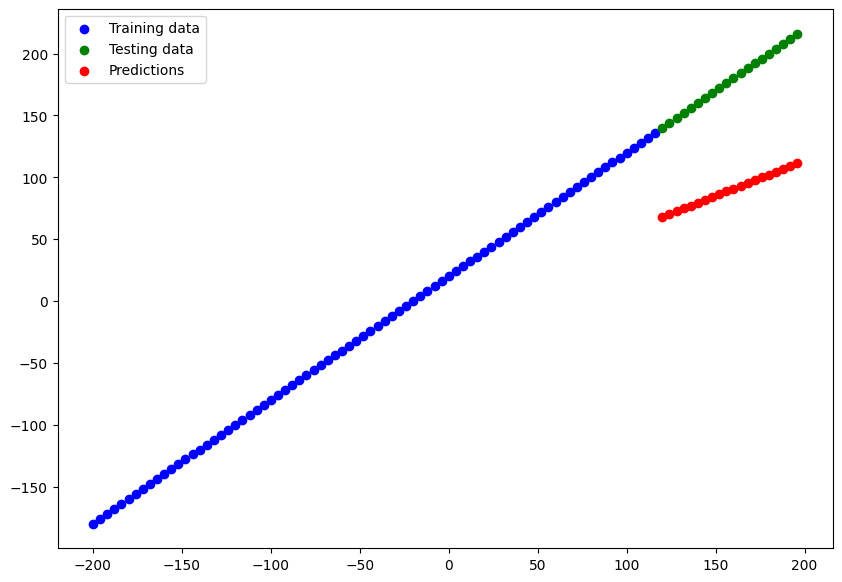

In [13]:
pred1 = model1.predict(x_test)

pltpred(x_train, y_train,
        x_test, y_test,
        pred1
        )

#### **Model 2 - Improved Single Neuron Approach**

Same setup as Model 1 but with some modifications such as increasing epoch count and using normalized features for `.fit()`.

##### Create and compile model

In [14]:
model2 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model2.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mse"]
              )

##### Show model summary

In [15]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [16]:
history2 = model2.fit(x_train_scaled, y_train, 
                      epochs=600)

Epoch 1/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 9250.9346 - mse: 9250.9346
Epoch 2/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9183.4346 - mse: 9183.4346
Epoch 3/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9118.6670 - mse: 9118.6670 
Epoch 4/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9052.5713 - mse: 9052.5713
Epoch 5/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8990.1113 - mse: 8990.1113
Epoch 6/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8921.8174 - mse: 8921.8174
Epoch 7/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8860.6270 - mse: 8860.6270
Epoch 8/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8791.5225 - mse: 8791.5225
Epoch 9/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8733.8457 - mse: 8733.8457  
Epoch 10/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8666.9561 - mse: 8666.9561
Epoch 11/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8605.3281 - mse: 8605.3281
Epoch 12/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 

Evaluate the model.

In [17]:
model2.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 38.0807 - mse: 38.0807


[38.080650329589844, 38.080650329589844]

##### Showcase results.

In [18]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

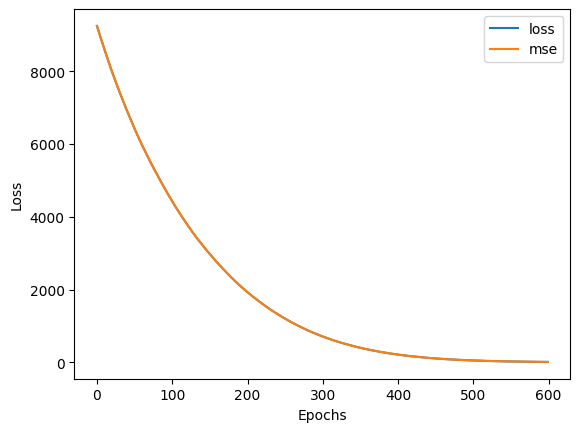

In [19]:
pd.DataFrame(history2.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


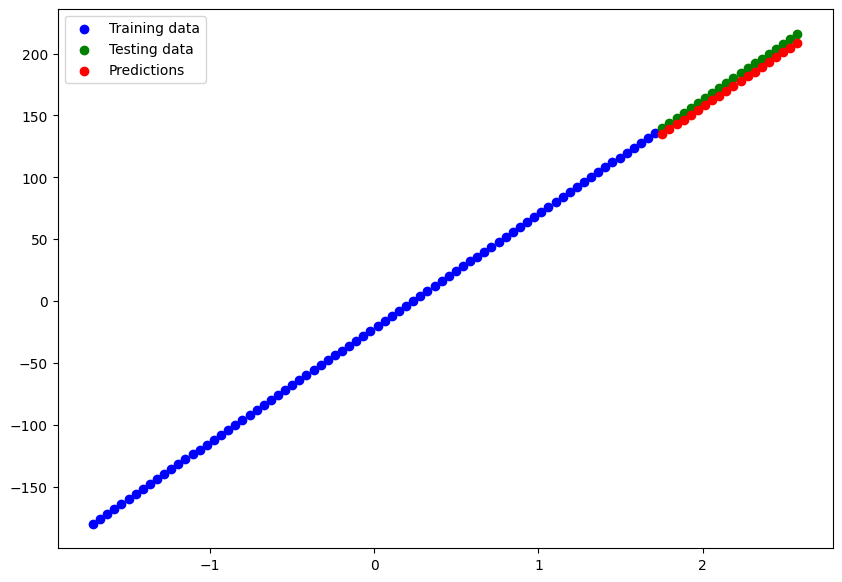

In [20]:
pred2 = model2.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred2
        )

#### **Model 3 - Two Layer Approach**

A model with two layers with the same neuron.

##### Create and compile model

In [28]:
model3 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

model3.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mse"]
              )

##### Show model summary

In [29]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [30]:
history3 = model3.fit(x_train_scaled, y_train, 
                      epochs=400)

Epoch 1/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 8659.9023 - mse: 8659.9023
Epoch 2/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8640.7822 - mse: 8640.7822
Epoch 3/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8622.6172 - mse: 8622.6172
Epoch 4/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8605.0449 - mse: 8605.0449  
Epoch 5/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8584.0088 - mse: 8584.0088
Epoch 6/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8566.3242 - mse: 8566.3242  
Epoch 7/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8544.8359 - mse: 8544.8359
Epoch 8/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8524.8369 - mse: 8524.8369
Epoch 9/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8504.3447 - mse: 8504.3447
Epoch 10/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8483.5420 - mse: 8483.5420
Epoch 11/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8461.5195 - mse: 8461.5195
Epoch 12/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss:

Evaluate the model.

In [31]:
model3.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 0.2477 - mse: 0.2477


[0.24771106243133545, 0.24771106243133545]

##### Showcase results.

In [35]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

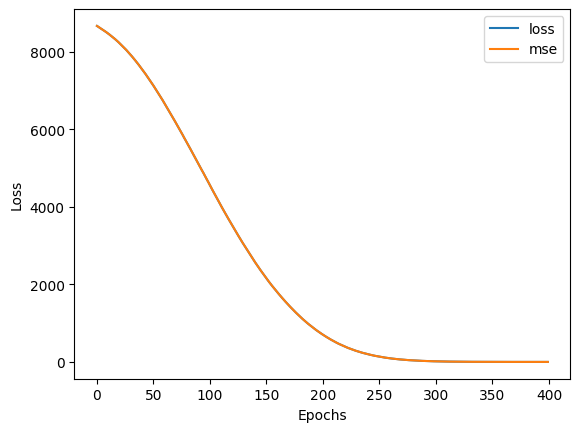

In [36]:
pd.DataFrame(history3.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


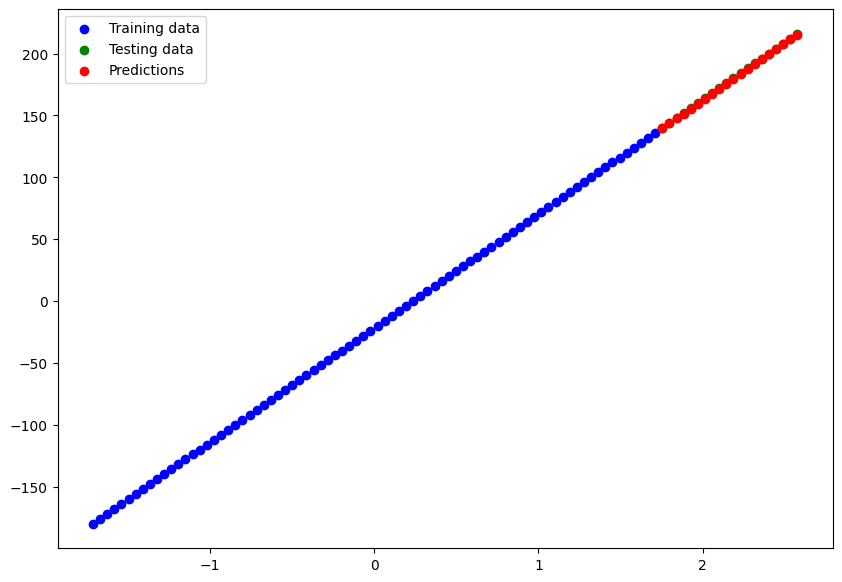

In [37]:
pred3 = model3.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred3
        )